In [ ]:
# ==============================
# Import Required Libraries
# ==============================

# Basic utilities
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')   # Ignore warnings for clean output

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ==============================
# Import Dataset from KaggleHub
# ==============================
import kagglehub

# Download dataset
path = kagglehub.dataset_download("ouaillaamiri02/furniture-and-essentials-image-dataset-5-classes")
print("Path to dataset files:", path)

# ==============================
# Load Dataset using Keras
# ==============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset directories
train_dir = os.path.join(path, "data/train")
val_dir   = os.path.join(path, "data/val")
test_dir  = os.path.join(path, "data/test")

100%|██████████| 87.2M/87.2M [00:02<00:00, 33.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ouaillaamiri02/furniture-and-essentials-image-dataset-5-classes/versions/2


In [ ]:
# ==============================
# Dataset Overview & EDA
# ==============================
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from glob import glob
import numpy as np
from tensorflow.keras.preprocessing import image

# Function to count images per class in a given directory
def count_images_per_class(base_dir):
    class_counts = {}
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

# Count images in train, val, test
train_counts = count_images_per_class(train_dir)
val_counts   = count_images_per_class(val_dir)
test_counts  = count_images_per_class(test_dir)

print("Training set distribution:", train_counts)
print("Validation set distribution:", val_counts)
print("Test set distribution:", test_counts)

Training set distribution: {'person': 540, 'laptop': 1081, 'table': 331, 'chair': 211, 'book': 438}
Validation set distribution: {'person': 91, 'laptop': 156, 'table': 60, 'chair': 41, 'book': 72}
Test set distribution: {'person': 299, 'laptop': 514, 'table': 171, 'chair': 127, 'book': 219}


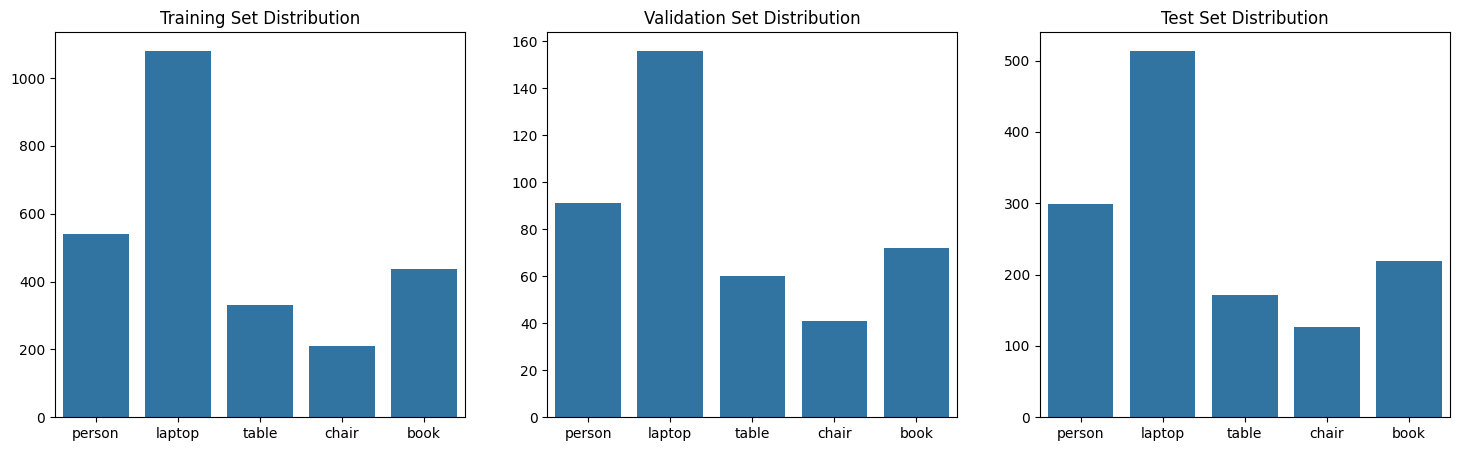

In [ ]:
# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0])
axes[0].set_title("Training Set Distribution")
sns.barplot(x=list(val_counts.keys()), y=list(val_counts.values()), ax=axes[1])
axes[1].set_title("Validation Set Distribution")
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[2])
axes[2].set_title("Test Set Distribution")
plt.show()

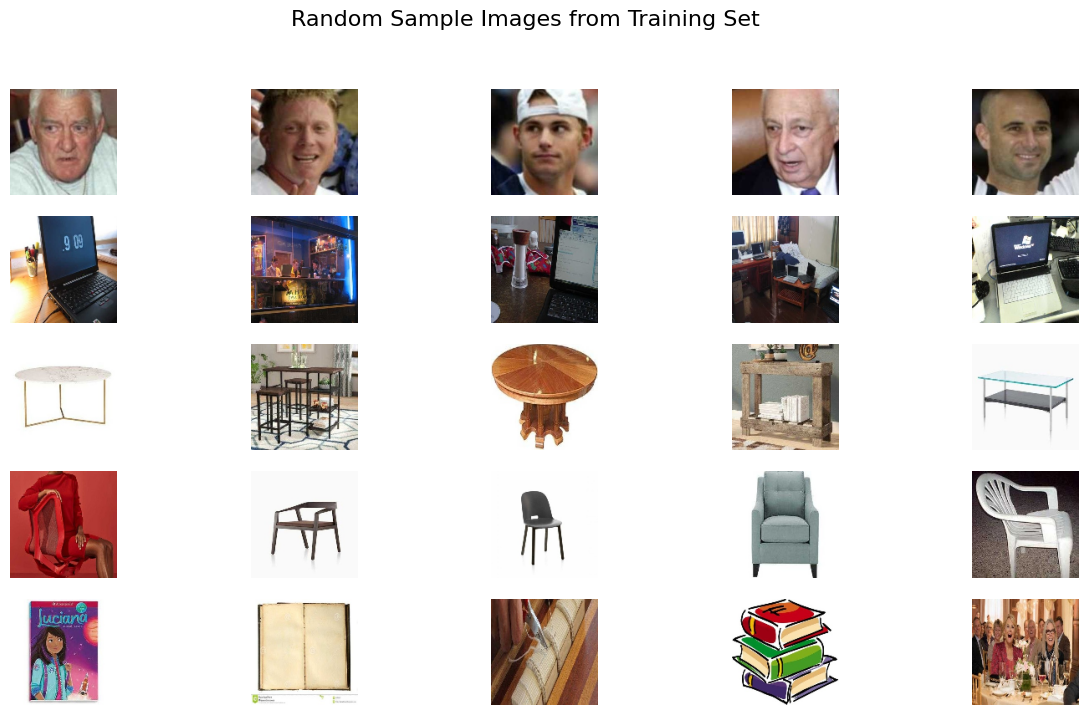

In [ ]:
# ==============================
# Display Random Sample Images
# ==============================
def show_sample_images(base_dir, n=5):
    all_classes = os.listdir(base_dir)
    plt.figure(figsize=(15, 8))
    for i, class_name in enumerate(all_classes):
        class_path = os.path.join(base_dir, class_name)
        sample_images = random.sample(os.listdir(class_path), n)
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = image.load_img(img_path, target_size=(128, 128))
            plt.subplot(len(all_classes), n, i*n + j + 1)
            plt.imshow(img)
            plt.axis("off")
            if j == 0:
                plt.ylabel(class_name, fontsize=12)
    plt.suptitle("Random Sample Images from Training Set", fontsize=16)
    plt.show()

show_sample_images(train_dir, n=5)

In [ ]:
# ==============================
# Data Preprocessing & Normalization
# ==============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and batch size
img_height, img_width = 224, 224
batch_size = 32

# Training data generator (with augmentation + normalization)
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalization [0,1]
    rotation_range=20,           # Random rotation
    width_shift_range=0.1,       # Horizontal shift
    height_shift_range=0.1,      # Vertical shift
    shear_range=0.2,             # Shearing
    zoom_range=0.2,              # Random zoom
    horizontal_flip=True,        # Random horizontal flip
    fill_mode='nearest'          # Fill in missing pixels
)

# Validation/Test data generator (only normalization)
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Load data
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Classes found:", train_gen.class_indices)

Found 2601 images belonging to 5 classes.
Found 420 images belonging to 5 classes.
Found 1330 images belonging to 5 classes.
Classes found: {'book': 0, 'chair': 1, 'laptop': 2, 'person': 3, 'table': 4}


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 5)
Pixel value range (min/max): 0.0 1.0


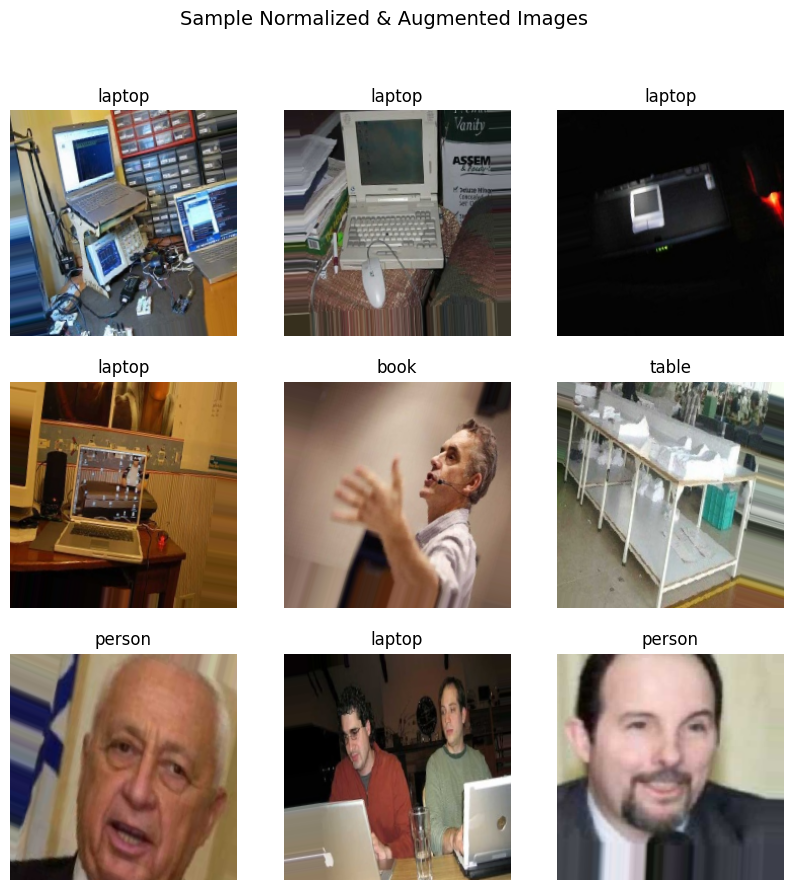

In [ ]:
# ==============================
# Show Sample Images After Normalization
# ==============================
import matplotlib.pyplot as plt

# Get one batch of images and labels
sample_images, sample_labels = next(train_gen)

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Pixel value range (min/max):", sample_images.min(), sample_images.max())

# Plot 9 sample images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])   # Already rescaled to [0,1]
    plt.title(list(train_gen.class_indices.keys())[np.argmax(sample_labels[i])])
    plt.axis("off")
plt.suptitle("Sample Normalized & Augmented Images", fontsize=14)
plt.show()

In [ ]:
# ==============================
# Model: Transfer Learning with MobileNetV2
# ==============================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Number of classes
num_classes = len(train_gen.class_indices)

# Load base model (without top layers)
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers (to prevent overfitting)
base_model.trainable = False

# Add custom classifier layers
x = base_model.output
x = GlobalAveragePooling2D()(x)           # Reduces dimensions
x = Dropout(0.3)(x)                       # Prevent overfitting
x = Dense(128, activation='relu')(x)      # Fully connected layer
x = Dropout(0.2)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Define model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ==============================
# Training & Evaluation
# ==============================
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "mobilenetv2_furniture_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.4568 - loss: 1.4386
Epoch 1: val_accuracy improved from -inf to 0.82143, saving model to mobilenetv2_furniture_best.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 86s 787ms/step - accuracy: 0.4586 - loss: 1.4340 - val_accuracy: 0.8214 - val_loss: 0.4936
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.7959 - loss: 0.5500
Epoch 2: val_accuracy improved from 0.82143 to 0.88571, saving model to mobilenetv2_furniture_best.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 411ms/step - accuracy: 0.7962 - loss: 0.5492 - val_accuracy: 0.8857 - val_loss: 0.3229
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8571 - loss: 0.3841
Epoch 3: val_accuracy improved from 0.88571 to 0.90000, saving model to mobilenetv2_furniture_best.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 34s 419ms/step - accuracy: 0.8573 - loss: 0.3838 - val_accuracy: 0.9000 - val_loss: 0.2680
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8817 - loss: 0.3380
Epoch 4: val_accuracy improved from 0.90000 to 0.90714, saving model to mobilenetv2_furniture_best.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 386ms/step - accuracy: 0.8818 - loss: 0.3378 - val_accuracy: 0.9071 - val_loss: 0.2488
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9105 - loss: 0.2561
Epoch 5: val_accuracy improved from 0.90714 to 0.92619, saving model to mobilenetv2_furniture_best.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 408ms/step - accuracy: 0.9104 - loss: 0.2561 - val_accuracy: 0.9262 - val_loss: 0.2225
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9172 - loss: 0.2552
Epoch 6: val_accuracy did not improve from 0.92619
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 392ms/step - accuracy: 0.9172 - loss: 0.2551 - val_accuracy: 0.9190 - val_loss: 0.2290
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9103 - loss: 0.2375
Epoch 7: val_accuracy improved from 0.92619 to 0.93095, saving model to mobilenetv2_furniture_best.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 44s 426ms/step - accuracy: 0.9103 - loss: 0.2376 - val_accuracy: 0.9310 - val_loss: 0.2154
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9162 - loss: 0.2227
Epoch 8: val_accuracy did not improve from 0.93095
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 402ms/step - accuracy: 0.9163 - loss: 0.2226 - val_accuracy: 0.9214 - val_loss: 0.2199
Epoch 9/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9307 - loss: 0.2099
Epoch 9: val_accuracy did not improve from 0.93095
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 395ms/step - accuracy: 0.9307 - loss: 0.2099 - val_accuracy: 0.9286 - val_loss: 0.2120
Epoch 10/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9237 - loss: 0.2004
Epoch 10: val_accuracy did not improve from 0.93095
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 401ms/step - accuracy: 0.9237 - loss: 0.2004 - val_accuracy: 0.9286 - val_loss: 0.2050


In [ ]:
# ==============================
# Evaluate on Test Set
# ==============================
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 310ms/step - accuracy: 0.9011 - loss: 0.2733

 Test Accuracy: 94.36%
Test Loss: 0.1709


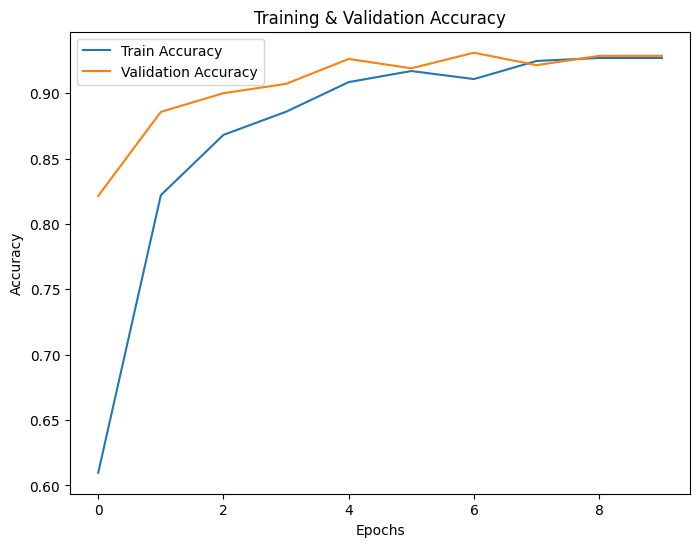

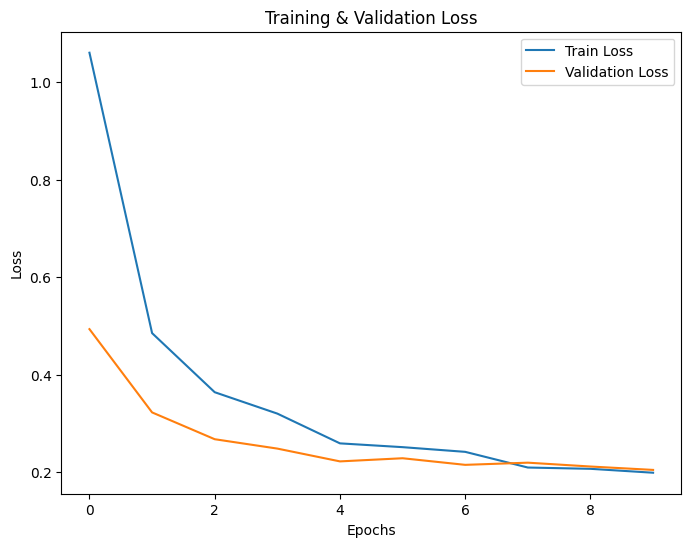

In [ ]:
# ==============================
# Plot Training History
# ==============================
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step


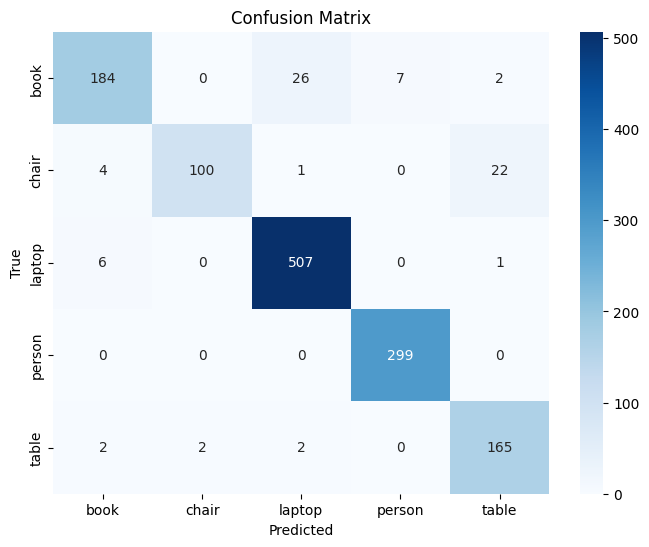

In [ ]:
# ==============================
# Confusion Matrix
# ==============================
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on test set
y_pred = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(train_gen.class_indices.keys()),
            yticklabels=list(train_gen.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(train_gen.class_indices.keys())))


Classification Report:

              precision    recall  f1-score   support

        book       0.94      0.84      0.89       219
       chair       0.98      0.79      0.87       127
      laptop       0.95      0.99      0.97       514
      person       0.98      1.00      0.99       299
       table       0.87      0.96      0.91       171

    accuracy                           0.94      1330
   macro avg       0.94      0.92      0.93      1330
weighted avg       0.95      0.94      0.94      1330



In [ ]:
# ==============================
# Save Model
# ==============================
# Save in new recommended Keras format
model.save("mobilenetv2_furniture_final.keras")
print(" Model saved as mobilenetv2_furniture_final.keras")

 Model saved as mobilenetv2_furniture_final.keras


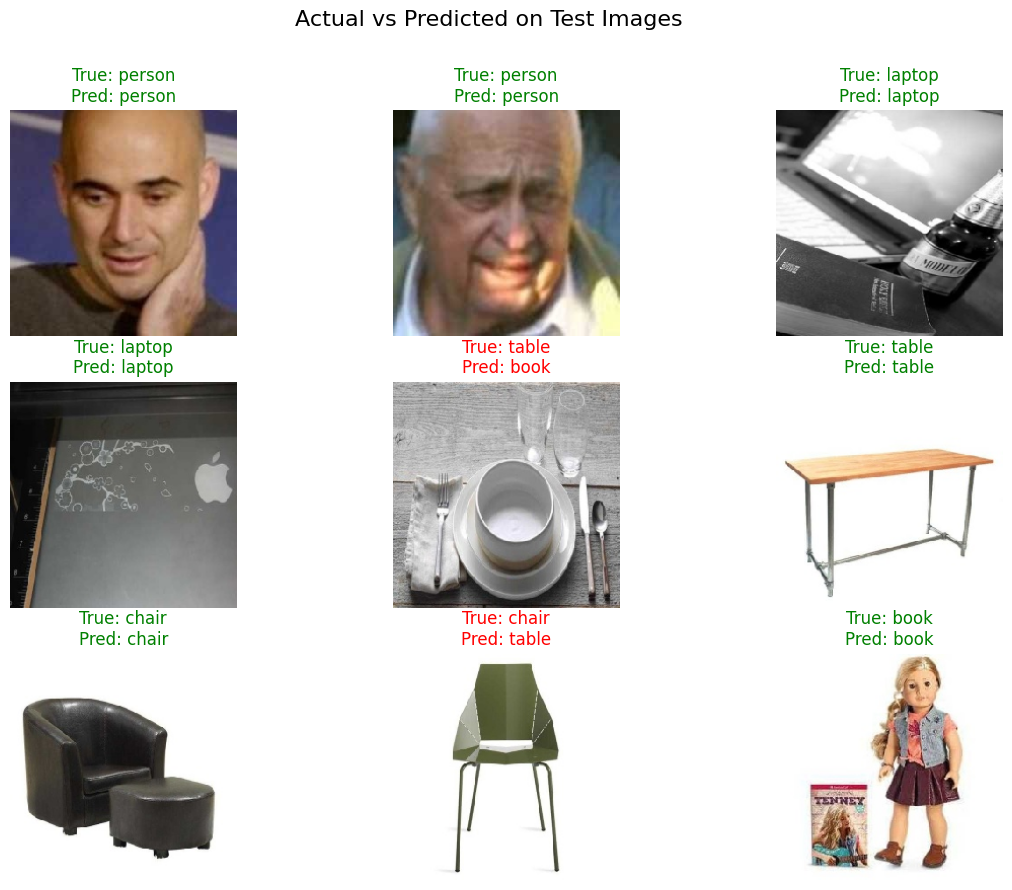

In [ ]:
# ==============================
# Test Model on Random Images
# ==============================
import matplotlib.pyplot as plt
import numpy as np
import random
from tensorflow.keras.preprocessing import image

# Class labels
class_labels = list(train_gen.class_indices.keys())

# Pick random test images
test_img_paths = []
for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        sample_images = random.sample(os.listdir(class_path), 2)  # pick 2 per class
        for img_name in sample_images:
            test_img_paths.append((os.path.join(class_path, img_name), class_name))

# Plot actual vs predicted
plt.figure(figsize=(14, 10))

for i, (img_path, true_label) in enumerate(test_img_paths[:9]):  # show 9 images
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_labels[np.argmax(prediction)]

    # Plot
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_label}\nPred: {predicted_class}",
              color="green" if true_label == predicted_class else "red")

plt.suptitle("Actual vs Predicted on Test Images", fontsize=16)
plt.show()